<a href="https://colab.research.google.com/github/phaniidk/-python-assignment-part4/blob/main/part4_visualization_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

# SETUP

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression


In [ ]:
# TASK 1 — DATA EXPLORATION WITH PANDAS


# Load dataset
df = pd.read_csv("students.csv")

print("\n===== TASK 1: DATA EXPLORATION =====")

# 1. First 5 rows
print("\nFirst 5 rows:")
print(df.head())

# 2. Shape and datatypes
print("\nShape:", df.shape)
print("\nData Types:")
print(df.dtypes)

# 3. Summary statistics
print("\nSummary Statistics:")
print(df.describe())

# 4. Pass/Fail count
print("\nPass/Fail Count:")
print(df["passed"].value_counts())

# 5. Average score per subject (Pass vs Fail)
subject_cols = ['math','science','english','history','pe']

print("\nAverage scores (Pass students):")
print(df[df['passed']==1][subject_cols].mean())

print("\nAverage scores (Fail students):")
print(df[df['passed']==0][subject_cols].mean())

# 6. Highest average student
df["avg"] = df[subject_cols].mean(axis=1)

print("\nTop Student:")
print(df.loc[df["avg"].idxmax()])



===== TASK 1: DATA EXPLORATION =====

First 5 rows:
      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  

Shape: (15, 9)

Data Types:
name                    object
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object

Summary Statistics:
   


===== TASK 2: MATPLOTLIB VISUALIZATION =====


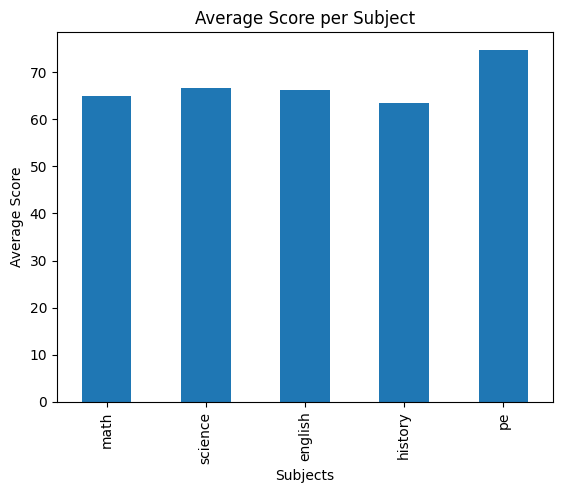

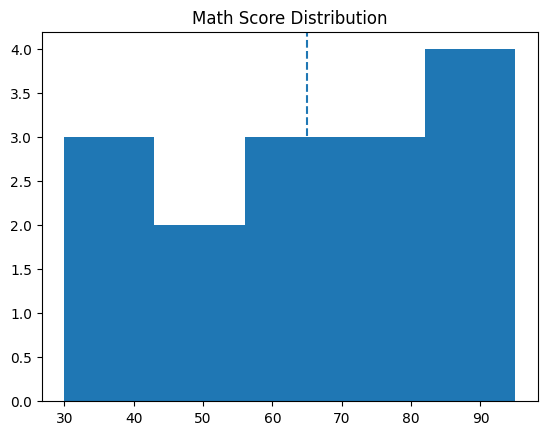

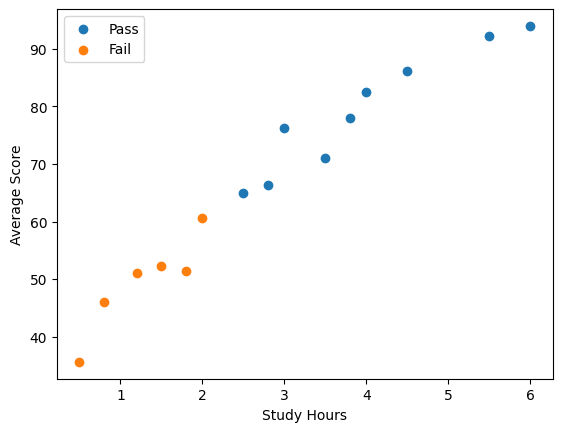

/tmp/ipykernel_15516/2653241742.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pass_df["attendance_pct"], fail_df["attendance_pct"]], labels=["Pass","Fail"])


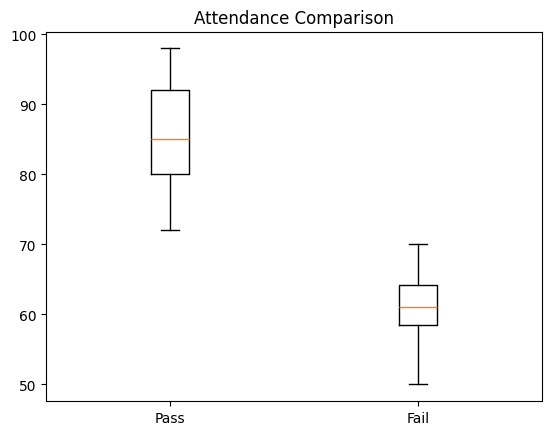

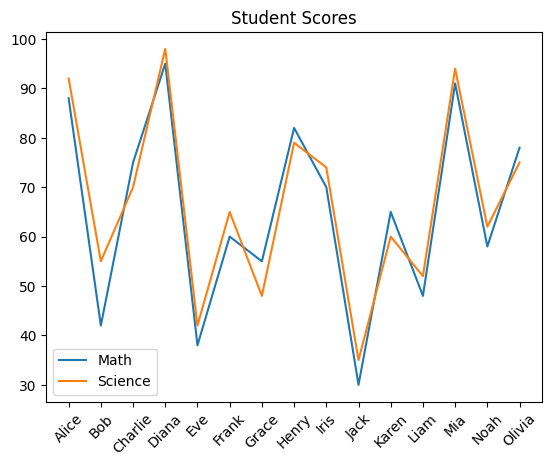

In [ ]:
# TASK 2 — DATA VISUALIZATION

print("\n===== TASK 2: MATPLOTLIB VISUALIZATION =====")

# Add avg_score
df["avg_score"] = df[subject_cols].mean(axis=1)

# 1. Bar Chart
plt.figure()
df[subject_cols].mean().plot(kind="bar")
plt.title("Average Score per Subject")
plt.xlabel("Subjects")
plt.ylabel("Average Score")
plt.show()

# 2. Histogram
plt.figure()
plt.hist(df["math"], bins=5)
plt.axvline(df["math"].mean(), linestyle="dashed")
plt.title("Math Score Distribution")
plt.show()

# 3. Scatter Plot
pass_df = df[df['passed']==1]
fail_df = df[df['passed']==0]

plt.figure()
plt.scatter(pass_df["study_hours_per_day"], pass_df["avg_score"], label="Pass")
plt.scatter(fail_df["study_hours_per_day"], fail_df["avg_score"], label="Fail")

plt.xlabel("Study Hours")
plt.ylabel("Average Score")
plt.legend()
plt.show()

# 4. Box Plot
plt.figure()
plt.boxplot([pass_df["attendance_pct"], fail_df["attendance_pct"]], labels=["Pass","Fail"])
plt.title("Attendance Comparison")
plt.show()

# 5. Line Plot
plt.figure()
plt.plot(df["name"], df["math"], label="Math")
plt.plot(df["name"], df["science"], label="Science")

plt.xticks(rotation=45)
plt.legend()
plt.title("Student Scores")
plt.show()



===== TASK 3: SEABORN VISUALIZATION =====


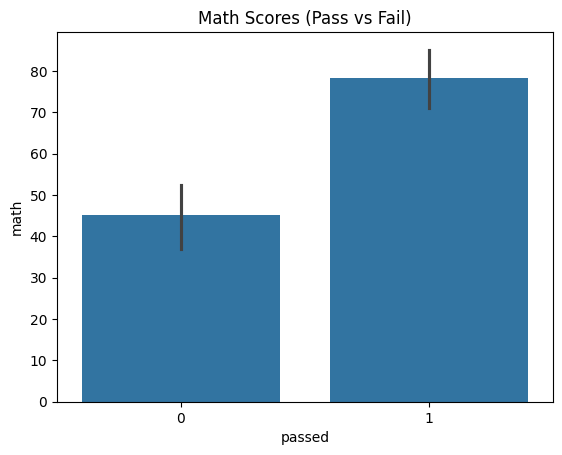

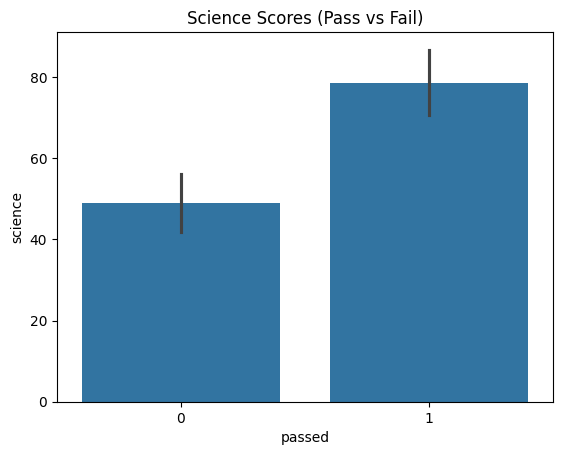

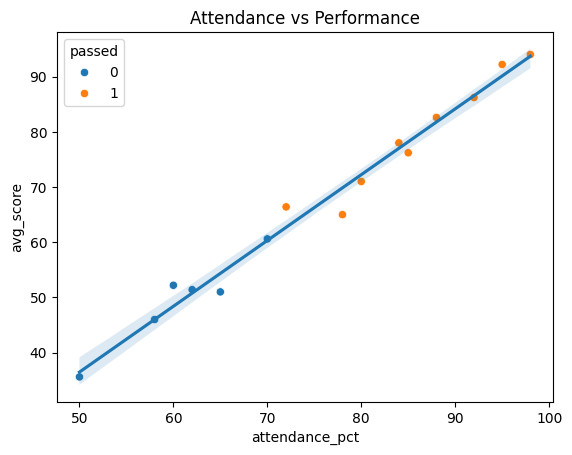

In [ ]:
# TASK 3 — DATA VISUALIZATION (SEABORN)


print("\n===== TASK 3: SEABORN VISUALIZATION =====")

# Bar plots
plt.figure()
sns.barplot(data=df, x="passed", y="math")
plt.title("Math Scores (Pass vs Fail)")
plt.show()

plt.figure()
sns.barplot(data=df, x="passed", y="science")
plt.title("Science Scores (Pass vs Fail)")
plt.show()

# Scatter + regression
plt.figure()
sns.scatterplot(data=df, x="attendance_pct", y="avg_score", hue="passed")
sns.regplot(data=df, x="attendance_pct", y="avg_score", scatter=False)
plt.title("Attendance vs Performance")
plt.show()

# COMMENT (IMPORTANT)
# Seaborn is easier for creating attractive visualizations quickly.
# Matplotlib gives more control but requires more code.



===== TASK 4: MACHINE LEARNING =====

Training Accuracy: 1.0
Test Accuracy: 1.0

Predictions:
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 1 | Predicted: 1

Feature Importance:
english : 0.8125127982724648
attendance_pct : 0.521876340433209
study_hours_per_day : 0.4844326627100155
pe : 0.47497406284967797
math : 0.43794393086873595
science : 0.3230097624690249
history : 0.26292892629062437


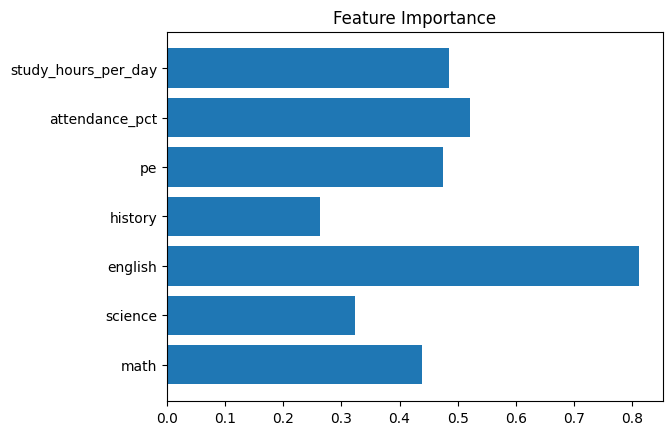


New Student Prediction: Pass
Probability: [[0.09203526 0.90796474]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
# TASK 4 — MACHINE LEARNING (SCIKIT-LEARN)


print("\n===== TASK 4: MACHINE LEARNING =====")

# Features and target
X = df[['math','science','english','history','pe','attendance_pct','study_hours_per_day']]
y = df['passed']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train model
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

print("\nTraining Accuracy:", model.score(X_train_scaled, y_train))

# Test model
y_pred = model.predict(X_test_scaled)
print("Test Accuracy:", model.score(X_test_scaled, y_test))

# Show predictions
print("\nPredictions:")
for i in range(len(y_pred)):
    print("Actual:", y_test.iloc[i], "| Predicted:", y_pred[i])

# Feature importance
print("\nFeature Importance:")
coeff = model.coef_[0]
for f, c in sorted(zip(X.columns, coeff), key=lambda x: abs(x[1]), reverse=True):
    print(f, ":", c)

# Plot feature importance
plt.figure()
plt.barh(X.columns, coeff)
plt.title("Feature Importance")
plt.show()

# New student prediction
new_student = [[75,70,68,65,80,82,3.2]]

scaled = scaler.transform(new_student)
pred = model.predict(scaled)
prob = model.predict_proba(scaled)

print("\nNew Student Prediction:", "Pass" if pred[0]==1 else "Fail")
print("Probability:", prob)